In [317]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [318]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [319]:
df=pd.read_csv('/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv')
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [320]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [321]:
df.shape

(17966, 9)

In [322]:
df.info

<bound method DataFrame.info of          model  year  price transmission  mileage fuelType  tax   mpg  \
0       Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7   
1        Focus  2018  14000       Manual     9083   Petrol  150  57.7   
2        Focus  2017  13000       Manual    12456   Petrol  150  57.7   
3       Fiesta  2019  17500       Manual    10460   Petrol  145  40.3   
4       Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7   
...        ...   ...    ...          ...      ...      ...  ...   ...   
17961    B-MAX  2017   8999       Manual    16700   Petrol  150  47.1   
17962    B-MAX  2014   7499       Manual    40700   Petrol   30  57.7   
17963    Focus  2015   9999       Manual     7010   Diesel   20  67.3   
17964       KA  2018   8299       Manual     5007   Petrol  145  57.7   
17965    Focus  2015   8299       Manual     5007   Petrol   22  57.7   

       engineSize  
0             1.0  
1             1.0  
2             1.0  
3          

In [323]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

<Axes: xlabel='price', ylabel='Count'>

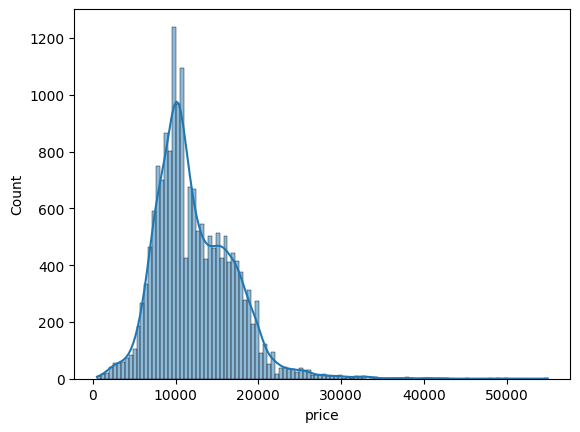

In [324]:
sns.histplot(df['price'],kde=True)

<Axes: >

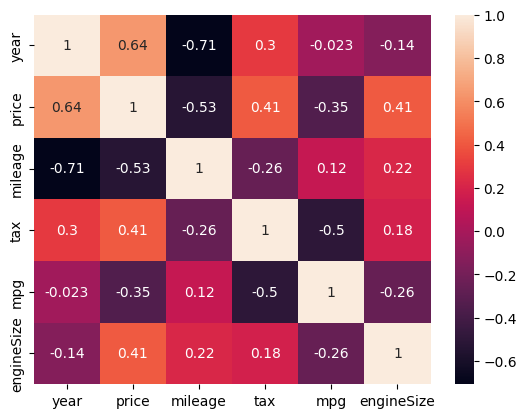

In [325]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

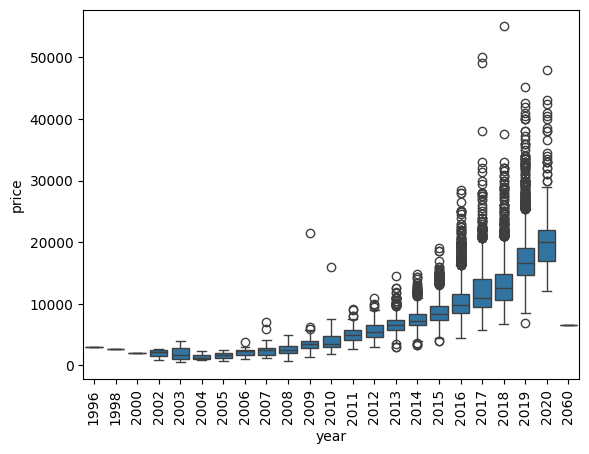

In [326]:
sns.boxplot(data=df,y='price',x='year')
plt.xticks(rotation=90)

<Axes: xlabel='mileage', ylabel='price'>

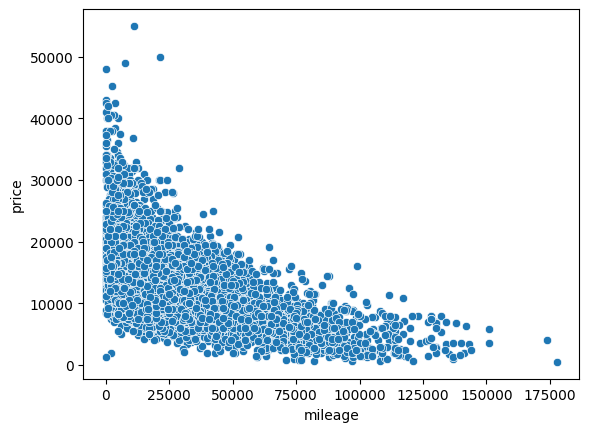

In [327]:
sns.scatterplot(data=df , x='mileage',y='price')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, '0.0'),
  Text(1, 0, '1.0'),
  Text(2, 0, '1.1'),
  Text(3, 0, '1.2'),
  Text(4, 0, '1.3'),
  Text(5, 0, '1.4'),
  Text(6, 0, '1.5'),
  Text(7, 0, '1.6'),
  Text(8, 0, '1.7'),
  Text(9, 0, '1.8'),
  Text(10, 0, '2.0'),
  Text(11, 0, '2.2'),
  Text(12, 0, '2.3'),
  Text(13, 0, '2.5'),
  Text(14, 0, '3.2'),
  Text(15, 0, '5.0')])

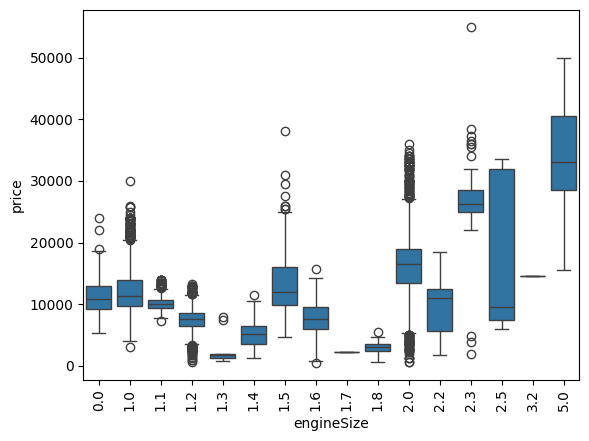

In [328]:
sns.boxplot(data=df,x='engineSize',y='price')
plt.xticks(rotation=90)

([0, 1, 2],
 [Text(0, 0, 'Automatic'), Text(1, 0, 'Manual'), Text(2, 0, 'Semi-Auto')])

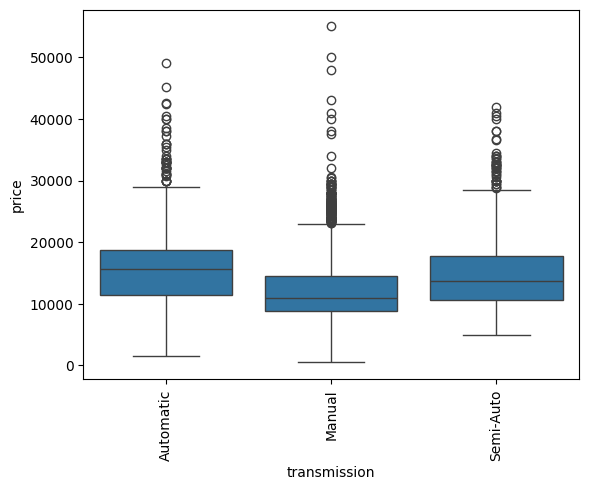

In [329]:
sns.boxplot(data=df,x='transmission',y='price')
plt.xticks(rotation=90)

<Axes: xlabel='fuelType', ylabel='price'>

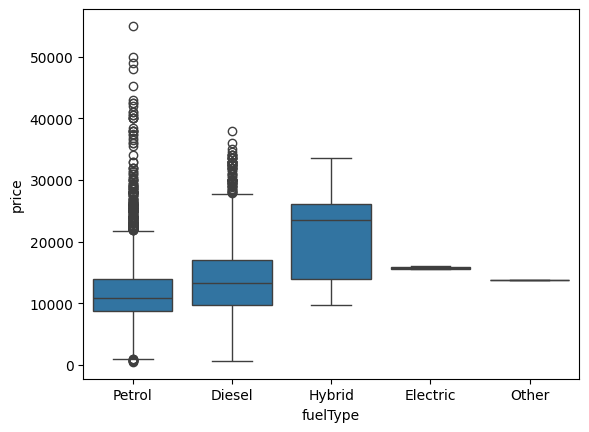

In [330]:
sns.boxplot(data=df,x='fuelType',y='price')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

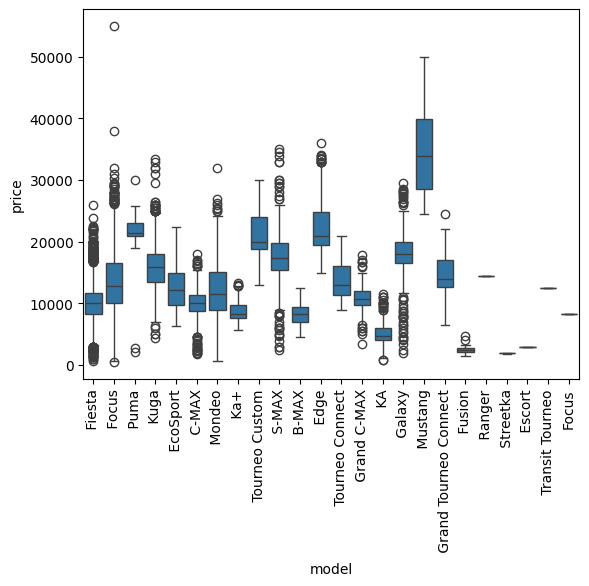

In [331]:
sns.boxplot(data=df,x='model',y='price')
plt.xticks(rotation=90)

(array([-100.,    0.,  100.,  200.,  300.,  400.,  500.,  600.,  700.]),
 [Text(-100.0, 0, '−100'),
  Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700')])

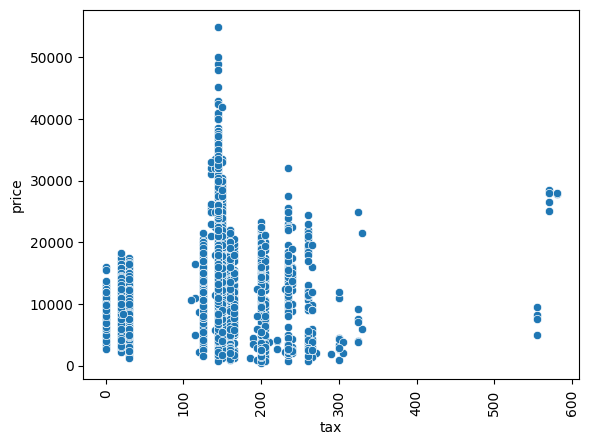

In [332]:
sns.scatterplot(data=df,y='price',x='tax')
plt.xticks(rotation=90)

(array([  0.,  25.,  50.,  75., 100., 125., 150., 175., 200., 225.]),
 [Text(0.0, 0, '0'),
  Text(25.0, 0, '25'),
  Text(50.0, 0, '50'),
  Text(75.0, 0, '75'),
  Text(100.0, 0, '100'),
  Text(125.0, 0, '125'),
  Text(150.0, 0, '150'),
  Text(175.0, 0, '175'),
  Text(200.0, 0, '200'),
  Text(225.0, 0, '225')])

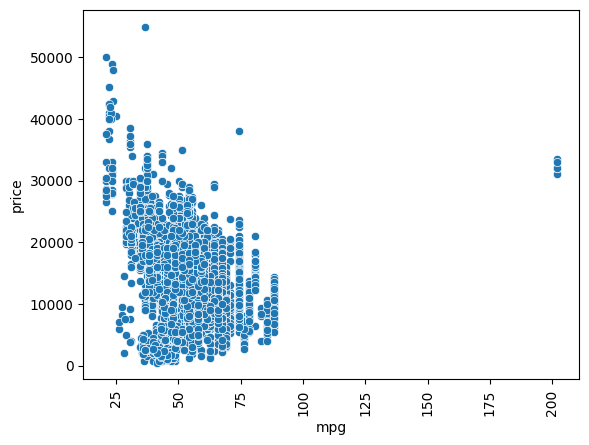

In [333]:
sns.scatterplot(data=df,y='price',x='mpg')
plt.xticks(rotation=90)

In [334]:
X2=df.drop(columns=['price'],axis=1)

In [335]:
df.columns


Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [336]:
X=df.drop(columns=['price','mpg'],axis=1)
y=df['price']

In [337]:
X_encoded=pd.get_dummies(X,columns=['transmission','model','fuelType'],drop_first=True)

In [338]:
X_encoded=X_encoded.astype(int)

In [339]:
from sklearn.preprocessing import LabelEncoder

In [340]:
Xlabel = X2
columns = ['transmission', 'fuelType', 'model']
label_encoders={}
for i in columns:
    encoder = LabelEncoder()  
    Xlabel[i] = encoder.fit_transform(Xlabel[i])
    label_encoders[i]=encoder

In [341]:
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [342]:
from sklearn.preprocessing import StandardScaler

In [343]:
numeric_columns=['year','mileage','tax','engineSize']
scaler=StandardScaler()
X_encoded[numeric_columns]=scaler.fit_transform(X_encoded[numeric_columns])

In [344]:
X_encoded

,year,mileage,tax,engineSize,transmission_Manual,transmission_Semi-Auto,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.447984,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.447984,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.447984,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-0.447984,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.447984,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-0.447984,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.447984,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,-0.447984,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.447984,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [345]:
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [346]:
Xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax',
       'engineSize']]=scaler.fit_transform(Xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax',
       'engineSize']])
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,57.7,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,57.7,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,57.7,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,40.3,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,48.7,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,47.1,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,57.7,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,67.3,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,57.7,-0.348804


In [347]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [354]:
 X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.33, random_state=42)

In [355]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [356]:
ypred=model.predict(X_test)

In [357]:
ypred

array([ 7245.69850238,  9969.45352697,  8728.34184208, ...,
       18085.47059946,  4951.19108491, 10558.12022999], shape=(5929,))

In [358]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [359]:
r2_score(y_test,ypred)

0.8264862659041357